Noisy-representation V* converged after 55 iterations.
c = 0.03
sigma_repr = 0.25
tau_exec = 0.025
Subjective lower boundary: L = -0.748, b = 0.152
Subjective upper boundary: L = 0.748, b = 0.848


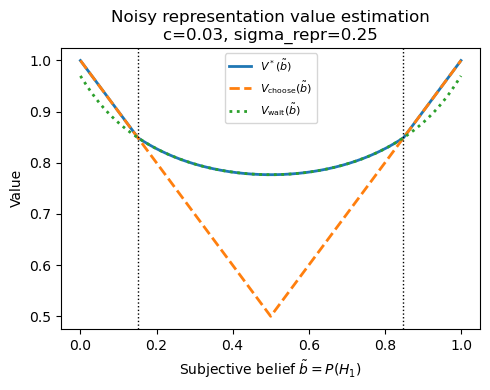

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

# ============================================================
# Mixed case:
# Noisy evidence representation + stochastic action execution
# Infinite horizon
# ============================================================

# -----------------------------
# Main parameters
# -----------------------------

c = 0.03
sigma_repr = 0.25
tau_exec = 0.025

R_correct = 1.0
R_wrong = 0.0

n_trials = 5 * 10**4
max_timestep = 10

rng = np.random.default_rng(1)

# ============================================================
# 1. Define 16 stimulus types and pA / pB
# ============================================================

mu = 2.2
sigma = 5.0
x = np.linspace(-15, 15, 500)

pdf_left = norm.pdf(x, -mu, sigma)    # H0 / Target A
pdf_right = norm.pdf(x, mu, sigma)    # H1 / Target B

# log10 likelihood ratio
log_ratio = np.log10(pdf_right / pdf_left)

target_log_ratios = np.array([
    -0.8, -0.7, -0.6, -0.5,
    -0.4, -0.3, -0.2, -0.1,
     0.1,  0.2,  0.3,  0.4,
     0.5,  0.6,  0.7,  0.8
])

x_targets = np.interp(target_log_ratios, log_ratio, x)

pB_raw = norm.pdf(x_targets, mu, sigma)
pA_raw = norm.pdf(x_targets, -mu, sigma)

pB = pB_raw / pB_raw.sum()
pA = pA_raw / pA_raw.sum()

# ============================================================
# 2. Subjective log10-odds grid
# ============================================================

L_min = -4.0
L_max = 4.0
N_L = 2001

L_grid = np.linspace(L_min, L_max, N_L)

# Subjective belief from subjective log10 odds
b_grid = 1.0 / (1.0 + 10.0 ** (-L_grid))

# Action values for choosing
Q0 = 1 - b_grid
Q1 = b_grid
V_choose = np.maximum(Q0, Q1)

# ============================================================
# 3. Helper functions
# ============================================================

def interp_value_L(L_query, L_grid, V):
    """
    Interpolate value over subjective log10 odds.
    """
    L_query = np.clip(L_query, L_grid[0], L_grid[-1])
    return np.interp(L_query, L_grid, V)


def softmax_3actions(Q0, Q1, QW, tau):
    """
    Softmax execution policy over:
        0 = choose H0
        1 = choose H1
        2 = sample / wait
    """
    Q_stack = np.vstack([Q0, Q1, QW]) / tau
    Q_stack = Q_stack - np.max(Q_stack, axis=0, keepdims=True)
    exp_Q = np.exp(Q_stack)
    return exp_Q / np.sum(exp_Q, axis=0, keepdims=True)


# Gauss-Hermite quadrature for representation noise
n_gh = 201
gh_x, gh_w = np.polynomial.hermite.hermgauss(n_gh)

noise_nodes = np.sqrt(2.0) * sigma_repr * gh_x
noise_weights = gh_w / np.sqrt(np.pi)

# ============================================================
# 4. Infinite-horizon value iteration in subjective state
#    Value estimation is independent of stochastic execution.
# ============================================================

def compute_noisy_repr_V_star(
    pA,
    pB,
    evidence_log10,
    c,
    L_grid,
    b_grid,
    V_choose,
    tol=1e-9,
    max_iter=5000
):
    """
    Infinite-horizon value iteration for noisy representation observer.

    Internal state:
        subjective log10 odds L_tilde

    Update:
        L_tilde_next = L_tilde + ell_i + epsilon
        epsilon ~ N(0, sigma_repr^2)

    Value estimation is deterministic max over action values.
    Stochastic execution is applied later.
    """

    V = V_choose.copy()

    for iteration in range(max_iter):

        V_old = V.copy()
        Q_wait = np.zeros_like(L_grid)

        for i, ell_i in enumerate(evidence_log10):

            # Subjective predictive probability of stimulus i
            q_i = b_grid * pB[i] + (1 - b_grid) * pA[i]

            expected_over_noise = np.zeros_like(L_grid)

            for node, weight in zip(noise_nodes, noise_weights):

                L_next = L_grid + ell_i + node

                expected_over_noise += weight * interp_value_L(
                    L_next,
                    L_grid,
                    V_old
                )

            Q_wait += q_i * expected_over_noise

        Q_wait = -c + Q_wait

        V = np.maximum(V_choose, Q_wait)

        diff = np.max(np.abs(V - V_old))

        if diff < tol:
            print(f"Noisy-representation V* converged after {iteration + 1} iterations.")
            break

    else:
        print("Warning: value iteration did not converge.")

    return V, Q_wait


V_star, Q_wait = compute_noisy_repr_V_star(
    pA=pA,
    pB=pB,
    evidence_log10=target_log_ratios,
    c=c,
    L_grid=L_grid,
    b_grid=b_grid,
    V_choose=V_choose
)

# ============================================================
# 5. Hard indifference boundaries in subjective space
# ============================================================

continue_region = Q_wait > V_choose

if np.any(continue_region):
    lower_L = L_grid[continue_region][0]
    upper_L = L_grid[continue_region][-1]
else:
    lower_L = 0.0
    upper_L = 0.0

lower_b = 1.0 / (1.0 + 10.0 ** (-lower_L))
upper_b = 1.0 / (1.0 + 10.0 ** (-upper_L))

print(f"c = {c}")
print(f"sigma_repr = {sigma_repr}")
print(f"tau_exec = {tau_exec}")
print(f"Subjective lower boundary: L = {lower_L:.3f}, b = {lower_b:.3f}")
print(f"Subjective upper boundary: L = {upper_L:.3f}, b = {upper_b:.3f}")

# ============================================================
# 6. Softmax stochastic execution policy in subjective space
# ============================================================

policy_probs = softmax_3actions(
    Q0,
    Q1,
    Q_wait,
    tau_exec
)

p_choose0 = policy_probs[0, :]
p_choose1 = policy_probs[1, :]
p_sample_subjective = policy_probs[2, :]

# ============================================================
# 7. Plot V_choose and V_wait from stabilized value iteration
# ============================================================

plt.figure(figsize=(5, 4))

plt.plot(
    b_grid,
    V_star,
    linewidth=2,
    label=r"$V^*(\tilde b)$"
)

plt.plot(
    b_grid,
    V_choose,
    "--",
    linewidth=2,
    label=r"$V_{\mathrm{choose}}(\tilde b)$"
)

plt.plot(
    b_grid,
    Q_wait,
    ":",
    linewidth=2,
    label=r"$V_{\mathrm{wait}}(\tilde b)$"
)

plt.axvline(lower_b, color="black", linestyle=":", linewidth=1)
plt.axvline(upper_b, color="black", linestyle=":", linewidth=1)

plt.xlabel(r"Subjective belief $\tilde b=P(H_1)$")
plt.ylabel("Value")
plt.title(
    f"Noisy representation value estimation\n"
    f"c={c}, sigma_repr={sigma_repr}"
)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 8. Simulate 5*10^4 trials
# ============================================================

sim_rows = []

for trial in range(n_trials):

    true_H = rng.integers(0, 2)  # 0 = H0/A, 1 = H1/B

    L_true = 0.0
    L_subj = 0.0

    for t in range(1, max_timestep + 1):

        if true_H == 0:
            stim_idx = rng.choice(len(pA), p=pA)
        else:
            stim_idx = rng.choice(len(pB), p=pB)

        ell = target_log_ratios[stim_idx]

        # Ground-truth cumulative log10 odds
        L_true += ell

        # Subjective noisy representation with perfect integration
        L_subj += ell + rng.normal(0.0, sigma_repr)

        b_true = 1.0 / (1.0 + 10.0 ** (-L_true))
        b_subj = 1.0 / (1.0 + 10.0 ** (-L_subj))

        q0_t = np.interp(L_subj, L_grid, Q0)
        q1_t = np.interp(L_subj, L_grid, Q1)
        qw_t = np.interp(L_subj, L_grid, Q_wait)

        probs_t = softmax_3actions(
            np.array([q0_t]),
            np.array([q1_t]),
            np.array([qw_t]),
            tau_exec
        ).flatten()

        action = rng.choice([0, 1, 2], p=probs_t)

        sim_rows.append({
            "trial": trial,
            "true_H": true_H,
            "time_step": t,
            "stim_idx": stim_idx,
            "ground_L": L_true,
            "subjective_L": L_subj,
            "ground_b": b_true,
            "subjective_b": b_subj,
            "action": action,
            "p_choose0": probs_t[0],
            "p_choose1": probs_t[1],
            "p_sample": probs_t[2]
        })

        if action in [0, 1]:
            break

df_sim = pd.DataFrame(sim_rows)

print(df_sim.head())
print(df_sim["action"].value_counts())

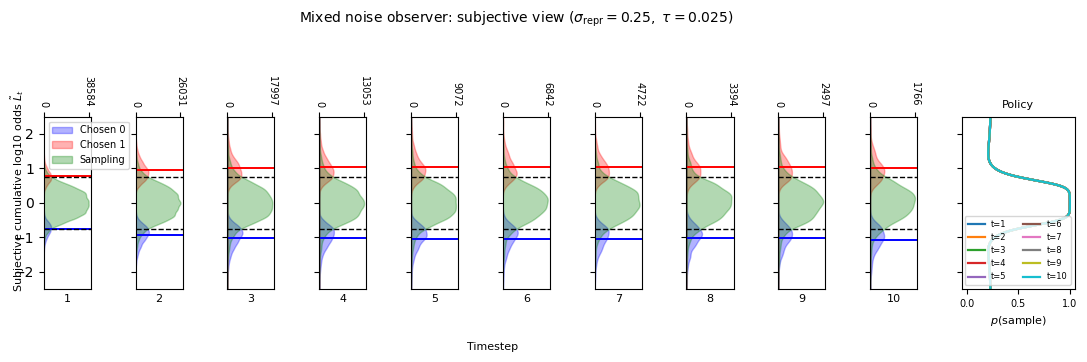

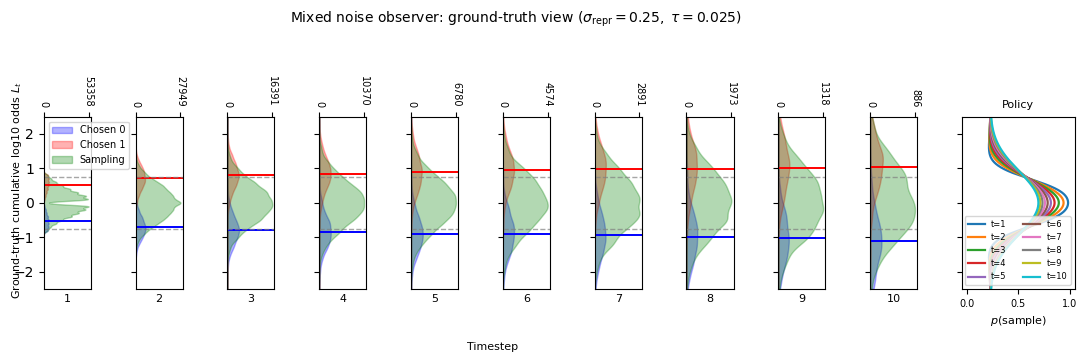

In [4]:
# ============================================================
# 9. Policy helpers for subjective and ground-truth views
# ============================================================

colors = {
    0: "blue",
    1: "red",
    2: "green"
}

labels = {
    0: "Chosen 0",
    1: "Chosen 1",
    2: "Sampling"
}

time_colors = plt.cm.tab10(np.arange(max_timestep))

def empirical_policy_by_bins(
    df,
    y_col,
    y_min,
    y_max,
    n_bins=60,
    min_count=10
):
    """
    Empirical p(sample) as a function of y_col by timestep.
    """
    bins = np.linspace(y_min, y_max, n_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])

    out = {}

    for t in range(1, max_timestep + 1):

        dft = df[df["time_step"] == t]

        y = dft[y_col].to_numpy()
        is_sample = (dft["action"] == 2).astype(float).to_numpy()

        p_emp = np.full_like(centers, np.nan, dtype=float)

        for k in range(n_bins):

            mask = (y >= bins[k]) & (y < bins[k + 1])

            if mask.sum() >= min_count:
                p_emp[k] = is_sample[mask].mean()

        out[t] = p_emp

    return centers, out


def p_sample_ground_view(y_grid, t):
    """
    Experimenter's ground-truth view:
    p(sample | ground L, t)

    Since L_subj = L_true + accumulated Gaussian noise,
    and representation noise accumulates as sigma_repr * sqrt(t),

    p(sample | L_true, t)
        = E_noise [ p_sample_subjective(L_true + noise) ].
    """
    s_t = sigma_repr * np.sqrt(t)

    if s_t == 0:
        return np.interp(y_grid, L_grid, p_sample_subjective)

    nodes_t = np.sqrt(2.0) * s_t * gh_x
    weights_t = gh_w / np.sqrt(np.pi)

    p_out = np.zeros_like(y_grid)

    for node, weight in zip(nodes_t, weights_t):

        p_out += weight * np.interp(
            y_grid + node,
            L_grid,
            p_sample_subjective,
            left=p_sample_subjective[0],
            right=p_sample_subjective[-1]
        )

    return p_out


# ============================================================
# 10. Plotting function
# ============================================================

def plot_mixed_noise_view(
    df,
    y_col,
    y_label,
    title,
    ground_truth_view=False
):

    fig, axes = plt.subplots(
        1,
        max_timestep + 1,
        figsize=(11.5, 3.4),
        sharey=True,
        gridspec_kw={"width_ratios": [1] * max_timestep + [2.4]}
    )

    dist_axes = axes[:-1]
    policy_ax = axes[-1]

    y_min = -2.5
    y_max = 2.5
    y_grid = np.linspace(y_min, y_max, 500)

    # ------------------------------------------------------------
    # Left side: distributions + dark p(sample) shadow
    # ------------------------------------------------------------

    for t in range(1, max_timestep + 1):

        ax = dist_axes[t - 1]
        timestep_data = df[df["time_step"] == t]

        max_density = 0.0

        if ground_truth_view:
            p_sample_y = p_sample_ground_view(y_grid, t)
        else:
            p_sample_y = np.interp(
                y_grid,
                L_grid,
                p_sample_subjective,
                left=p_sample_subjective[0],
                right=p_sample_subjective[-1]
            )
            
        """
        # dark shadow: larger p(sample) = darker
        for k in range(len(y_grid) - 1):
            alpha_k = 1 - p_sample_y[k]
            if alpha_k > 0.003:
                ax.axhspan(
                    y_grid[k],
                    y_grid[k + 1],
                    color="black",
                    alpha=alpha_k,
                    linewidth=0
                )
        """

        for action in [0, 1, 2]:

            action_data = timestep_data[timestep_data["action"] == action]

            if action_data.empty:
                continue

            ev = action_data[y_col].to_numpy()

            if len(ev) < 3 or np.std(ev) == 0:
                continue

            kde = gaussian_kde(ev)
            density = kde(y_grid)

            density_scaled = density * len(ev)
            max_density = max(max_density, density_scaled.max())

            ax.fill_betweenx(
                y_grid,
                0,
                density_scaled,
                color=colors[action],
                alpha=0.3,
                label=labels[action] if t == 1 else None
            )

            if action in [0, 1]:
                mean_ev = np.mean(ev)
                ax.axhline(
                    mean_ev,
                    color=colors[action],
                    linewidth=1.4
                )

        if t == 1:
            ax.legend(loc="upper left", fontsize=7, frameon=True)

        # Subjective hard indifference lines.
        # In the ground-truth view, these are only reference centers;
        # the true visible boundary is the soft shadow.
        ax.axhline(
            lower_L,
            color="black" if not ground_truth_view else "gray",
            linestyle="--",
            linewidth=1,
            alpha=1.0 if not ground_truth_view else 0.7
        )

        ax.axhline(
            upper_L,
            color="black" if not ground_truth_view else "gray",
            linestyle="--",
            linewidth=1,
            alpha=1.0 if not ground_truth_view else 0.7
        )

        ax.set_ylim(y_min, y_max)

        if max_density > 0:
            ax.set_xlim(0, max_density * 1.05)
            ax.set_xticks([0, int(max_density)])
        else:
            ax.set_xlim(0, 1)
            ax.set_xticks([0, 1])

        ax.xaxis.set_ticks_position("top")
        ax.tick_params(
            axis="x",
            top=True,
            labeltop=True,
            labelbottom=False
        )

        ax.set_xticklabels(
            [str(int(x)) for x in ax.get_xticks()],
            rotation=270,
            fontsize=7
        )

        ax.set_xlabel(str(t), fontsize=8)

    # ------------------------------------------------------------
    # Right side: policy curves
    # ------------------------------------------------------------

    centers, empirical_policy = empirical_policy_by_bins(
        df,
        y_col=y_col,
        y_min=y_min,
        y_max=y_max,
        n_bins=60,
        min_count=10
    )

    for t in range(1, max_timestep + 1):

        if ground_truth_view:
            p_sample_y = p_sample_ground_view(y_grid, t)
        else:
            p_sample_y = np.interp(
                y_grid,
                L_grid,
                p_sample_subjective,
                left=p_sample_subjective[0],
                right=p_sample_subjective[-1]
            )

        color_t = time_colors[t - 1]

        # Optimal soft policy
        policy_ax.plot(
            p_sample_y,
            y_grid,
            color=color_t,
            linewidth=1.6,
            label=f"t={t}"
        )
        """
        # Empirical policy
        policy_ax.plot(
            empirical_policy[t],
            centers,
            color=color_t,
            linestyle="--",
            linewidth=1.1,
            alpha=0.85
        )
        """

    policy_ax.set_xlim(-0.05, 1.05)
    policy_ax.set_xticks([0, 0.5, 1.0])
    policy_ax.set_xlabel(r"$p(\mathrm{sample})$", fontsize=8)
    policy_ax.set_title("Policy", fontsize=8)
    policy_ax.tick_params(axis="x", labelsize=7)

    policy_ax.legend(
        loc="lower right",
        fontsize=6,
        ncol=2,
        frameon=True
    )

    fig.text(
        0.48,
        0.03,
        "Timestep",
        ha="center",
        fontsize=8
    )

    fig.text(
        0.06,
        0.5,
        y_label,
        va="center",
        rotation="vertical",
        fontsize=8
    )

    fig.suptitle(title, fontsize=10, y=1.03)

    for ax in dist_axes:
        ax.label_outer()

    plt.tight_layout(rect=[0.05, 0.05, 1, 0.98])
    plt.show()


# ============================================================
# 11A. Subjective view
# ============================================================

plot_mixed_noise_view(
    df=df_sim,
    y_col="subjective_L",
    y_label=r"Subjective cumulative log10 odds $\tilde L_t$",
    title=(
        "Mixed noise observer: subjective view "
        r"$(\sigma_{\mathrm{repr}}=0.25,\ \tau=0.025)$"
    ),
    ground_truth_view=False
)

# ============================================================
# 11B. Ground-truth view
# ============================================================

plot_mixed_noise_view(
    df=df_sim,
    y_col="ground_L",
    y_label=r"Ground-truth cumulative log10 odds $L_t$",
    title=(
        "Mixed noise observer: ground-truth view "
        r"$(\sigma_{\mathrm{repr}}=0.25,\ \tau=0.025)$"
    ),
    ground_truth_view=True
)